# Phase 1 — Feature engineering

Issue [#15](https://github.com/vks-g/cmapss-rul-hybrid/issues/15). This notebook shows the effect of operating-regime normalization, examines causal sensor features against training RUL, and writes aligned FD001 feature matrices for downstream models. FD002 supplies the six-regime comparison; FD001 is the primary exported subset. Data files are local and never committed.

**Leakage boundary.** Exploratory plots use official training trajectories only. Final export fits sensor selection and regime statistics on all official training engines, then transforms official test engines with those statistics. For cross-validation, refit both on each training fold; do not reuse the final exported matrix to tune folds.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from rul.data.load import load_subset
from rul.features.regimes import RegimeNormalizer

REPO_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "pyproject.toml").exists())
DATA_DIR = REPO_ROOT / "data" / "raw" / "CMAPSSData"
SEED = 42
assert DATA_DIR.exists(), f"Place C-MAPSS files in {DATA_DIR}"


## 1. What six-regime normalization changes

FD002 has six operating conditions. We fit a six-cluster normalizer on its training rows and compare regime means for three representative sensors. To make raw sensors comparable on one color scale, the left plot first uses a *global* z-score for display only. The right plot uses the actual regime-fitted normalized values. This descriptive plot uses no test data and makes no claim about model accuracy.

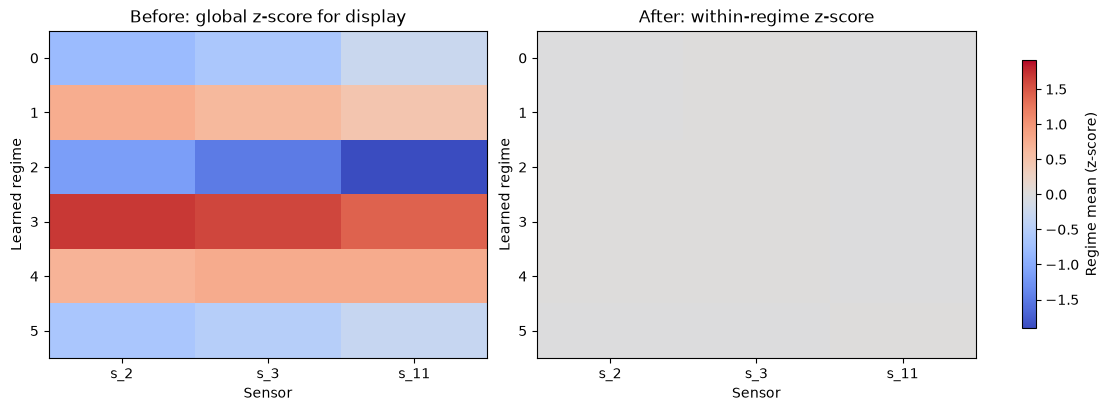

,before_global_z,after_regime_z
s_2,1.016594,1.964269e-13
s_3,1.031537,1.675449e-14
s_11,1.049667,8.973467e-15


In [2]:
fd002_train = load_subset("FD002", data_dir=DATA_DIR).train
fd002_normalizer = RegimeNormalizer(n_regimes=6, random_state=SEED).fit(fd002_train)
fd002_scaled = fd002_normalizer.transform(fd002_train)
plot_sensors = ["s_2", "s_3", "s_11"]
raw_global_z = (fd002_train[plot_sensors] - fd002_train[plot_sensors].mean()) / fd002_train[plot_sensors].std(ddof=0)
raw_regime_means = raw_global_z.groupby(fd002_scaled["regime"]).mean()
scaled_regime_means = fd002_scaled.groupby("regime")[plot_sensors].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
color_limit = max(1.0, np.abs(raw_regime_means.to_numpy()).max())
for ax, values, title in zip(
    axes,
    (raw_regime_means, scaled_regime_means),
    ("Before: global z-score for display", "After: within-regime z-score"),
):
    image = ax.imshow(values.to_numpy(), cmap="coolwarm", vmin=-color_limit, vmax=color_limit, aspect="auto")
    ax.set(xticks=range(len(plot_sensors)), xticklabels=plot_sensors,
           yticks=range(6), yticklabels=values.index, xlabel="Sensor", ylabel="Learned regime", title=title)
fig.colorbar(image, ax=axes, label="Regime mean (z-score)", shrink=0.82)
plt.show()

mean_dispersion = pd.DataFrame({
    "before_global_z": raw_regime_means.std(ddof=0),
    "after_regime_z": scaled_regime_means.std(ddof=0),
})
display(mean_dispersion)
assert np.abs(scaled_regime_means.to_numpy()).max() < 1e-10


The three sensors' regime-mean dispersion is about **one global standard deviation before normalization** and effectively zero afterward (the residual is floating-point rounding). This confirms removal of between-regime mean offsets in the training rows; it does not show improved RUL prediction by itself.

## 2. Causal features and remaining life

Build FD001 train and test features with the shared functions. Sensor selection uses **raw training rows**. The one-regime normalizer fits those same training rows and transforms both sets. Trailing windows use only each engine's observed history. The uncapped `rul` label is retained for training analysis, never included in `feature_columns` or the test matrix.

In [3]:
from rul.features.matrix import build_feature_matrices

fd001 = load_subset("FD001", data_dir=DATA_DIR)
matrices = build_feature_matrices(fd001.train, fd001.test, n_regimes=1, seed=SEED)
print(f"FD001: {len(matrices.train):,} training cycles, {len(matrices.test):,} test cycles")
print(f"Selected {len(matrices.sensors)} sensors and {len(matrices.feature_columns)} predictors")
print("Selected sensors:", ", ".join(matrices.sensors))
assert "rul" not in matrices.feature_columns and "rul" not in matrices.test
assert matrices.train["unit"].nunique() == 100
assert matrices.test["unit"].nunique() == 100


FD001: 20,631 training cycles, 13,096 test cycles
Selected 15 sensors and 155 predictors
Selected sensors: s_2, s_3, s_4, s_6, s_7, s_8, s_9, s_11, s_12, s_13, s_14, s_15, s_17, s_20, s_21


Spearman rank correlations summarize monotonic relationships across **training** cycles. They are descriptive: rows within one engine are correlated, and late cycles tend to have low RUL. Do not use these values to choose features for cross-validation without recomputing the choice inside each training fold.

,Spearman rho
cycle,-0.786844
s_4_mean_5,-0.754409
s_11_mean_5,-0.753346
s_4_mean_10,-0.753003
s_17_mean_10,-0.752267
s_21_mean_10,0.751519
s_15_mean_10,-0.749999
s_3_mean_10,-0.749657
s_11_mean_10,-0.748621
s_11_health_5,-0.747022


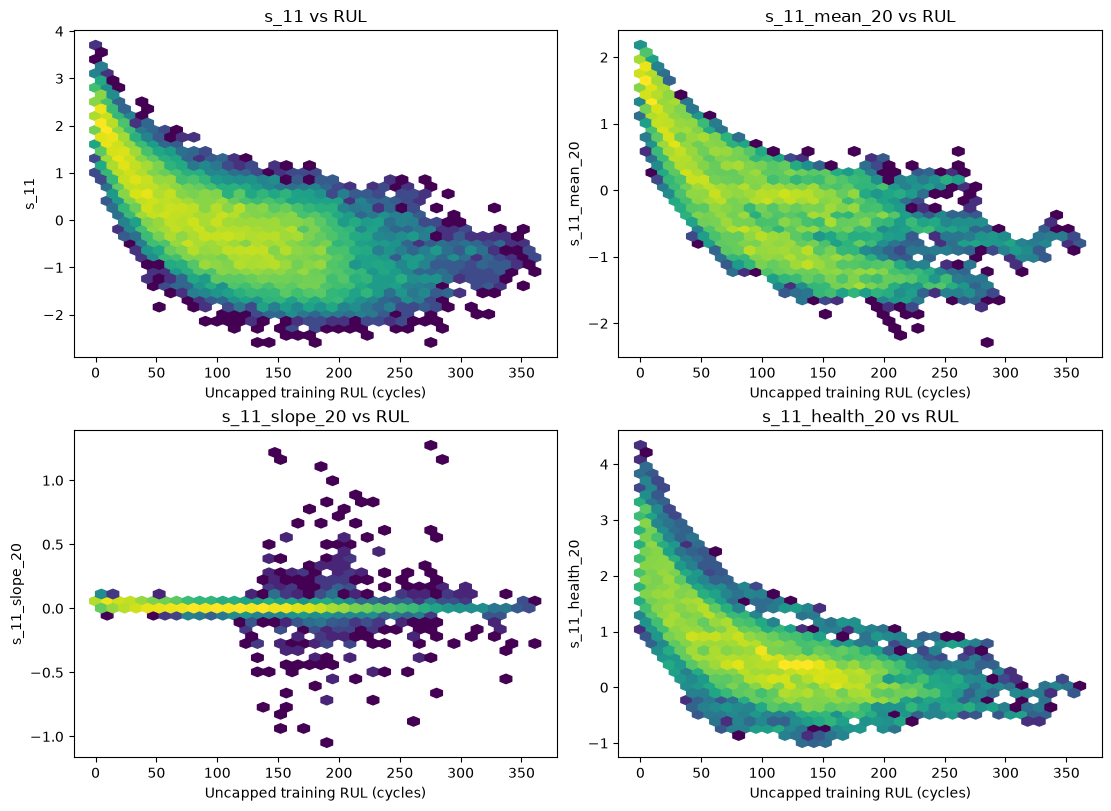

In [4]:
varying_features = [name for name in matrices.feature_columns if matrices.train[name].nunique() > 1]
correlations = matrices.train[varying_features].corrwith(matrices.train["rul"], method="spearman").dropna()
strongest = correlations.reindex(correlations.abs().sort_values(ascending=False).index).head(12)
display(strongest.rename("Spearman rho").to_frame())

relationship_features = ["s_11", "s_11_mean_20", "s_11_slope_20", "s_11_health_20"]
assert set(relationship_features).issubset(matrices.feature_columns)
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for ax, feature in zip(axes.flat, relationship_features):
    ax.hexbin(matrices.train["rul"], matrices.train[feature], gridsize=38,
              mincnt=1, bins="log", cmap="viridis")
    ax.set(xlabel="Uncapped training RUL (cycles)", ylabel=feature,
           title=f"{feature} vs RUL")
plt.show()


The strongest FD001 rank relationships include cycle and several rolling means (absolute Spearman rho about 0.75). For sensor `s_11`, its raw value, rolling mean, and signed health change move systematically with RUL; the short-window slope is much noisier. These are training-set descriptions, not held-out predictive scores or evidence of causation.